# 🌍 Remote Work e Resilienza Economica in Europa
**Corso:** Internet and Network Economics — LUISS

---

### File di input necessari (nella stessa cartella del notebook):
| File | Contenuto |
|------|-----------|
| `occupations_workathome.csv` | Dingel & Neiman: occupazioni remotizzabili |
| `combined_isco_gdp.json` | Eurostat: occupazione ISCO + PIL |
| `une_rt_a_unemployment.csv` | Eurostat: tasso di disoccupazione |
| `nama_10_lp_productivity.csv` | Eurostat: produttività del lavoro |

### Output:
- `final_dataset.csv`

---
## 📦 Blocco 0 — Import delle librerie

In [17]:
import pandas as pd   # per lavorare con tabelle (DataFrame)
import numpy as np    # per calcoli numerici
import json           # per leggere file .json
import io             # per convertire testo in file leggibili da pandas

print('Librerie caricate correttamente!')

Librerie caricate correttamente!


---
## ⚙️ Configurazione generale
Definiamo qui i dizionari e le liste che useremo in tutto il notebook.

In [18]:
# Lista dei 27 paesi UE (codici ISO a 2 lettere)
EU27 = [
    'AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES',
    'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT',
    'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK'
]

# Dizionario: codice ISO → nome completo del paese
NOMI_PAESI = {
    'AT': 'Austria',     'BE': 'Belgium',     'BG': 'Bulgaria',
    'CY': 'Cyprus',      'CZ': 'Czechia',     'DE': 'Germany',
    'DK': 'Denmark',     'EE': 'Estonia',     'EL': 'Greece',
    'ES': 'Spain',       'FI': 'Finland',     'FR': 'France',
    'HR': 'Croatia',     'HU': 'Hungary',     'IE': 'Ireland',
    'IT': 'Italy',       'LT': 'Lithuania',   'LU': 'Luxembourg',
    'LV': 'Latvia',      'MT': 'Malta',       'NL': 'Netherlands',
    'PL': 'Poland',      'PT': 'Portugal',    'RO': 'Romania',
    'SE': 'Sweden',      'SI': 'Slovenia',    'SK': 'Slovakia'
}

# Dizionario: codice ISO → macro-area geografica
REGIONI = {
    'AT': 'Nord/Ovest', 'BE': 'Nord/Ovest', 'DE': 'Nord/Ovest',
    'DK': 'Nord/Ovest', 'FI': 'Nord/Ovest', 'FR': 'Nord/Ovest',
    'IE': 'Nord/Ovest', 'LU': 'Nord/Ovest', 'NL': 'Nord/Ovest',
    'SE': 'Nord/Ovest',
    'CY': 'Sud', 'EL': 'Sud', 'ES': 'Sud', 'HR': 'Sud',
    'IT': 'Sud', 'MT': 'Sud', 'PT': 'Sud', 'SI': 'Sud',
    'BG': 'Est', 'CZ': 'Est', 'EE': 'Est', 'HU': 'Est',
    'LT': 'Est', 'LV': 'Est', 'PL': 'Est', 'RO': 'Est', 'SK': 'Est'
}

# Tabella di conversione: gruppo SOC (USA) → gruppo ISCO (Europa)
# Serve per tradurre i dati americani di Dingel & Neiman nel formato europeo
SOC_A_ISCO = {
    11: 1, 19: 1,
    13: 2, 15: 2, 17: 2, 21: 2,
    23: 3, 25: 3, 27: 3, 29: 3,
    43: 4,
    35: 5, 37: 5, 39: 5,
    45: 6,
    47: 7, 49: 7,
    51: 8,
    53: 9, 55: 9
}

print('Configurazione completata!')

Configurazione completata!


---
## 📂 Blocco 1 — Caricamento dei file
Leggiamo i 4 file di input che contengono i dati grezzi.

In [19]:
# File 1: dataset Dingel & Neiman
df_dn = pd.read_csv('occupations_workathome.csv')
print(f'Dingel-Neiman: {len(df_dn)} righe')

# File 2: dati Eurostat su occupazione ISCO e PIL, salvati insieme in un file JSON
with open('combined_isco_gdp.json') as f:
    combined = json.load(f)

df_isco_raw = pd.read_csv(io.StringIO(combined['isco']))
df_gdp_raw  = pd.read_csv(io.StringIO(combined['gdp']))
print(f'Occupazione ISCO: {len(df_isco_raw)} righe')
print(f'PIL:              {len(df_gdp_raw)} righe')

# File 3: tasso di disoccupazione (Eurostat)
df_unemp_raw = pd.read_csv('une_rt_a_unemployment.csv')
print(f'Disoccupazione:   {len(df_unemp_raw)} righe')

# File 4: produttività del lavoro (Eurostat)
df_prod_raw = pd.read_csv('nama_10_lp_productivity.csv')
print(f'Produttività:     {len(df_prod_raw)} righe')

Dingel-Neiman: 968 righe
Occupazione ISCO: 1458 righe
PIL:              162 righe
Disoccupazione:   37581 righe
Produttività:     63506 righe


---
## 📊 Blocco 2 — Calcolo dell'Indice di Remotizzabilità

**Idea di base:**
Ogni paese ha una certa quota di lavoratori per ogni gruppo ISCO (es. 10% sono dirigenti, 20% tecnici, ecc.).
Ogni gruppo ISCO ha una percentuale di lavori che possono essere fatti da remoto (da Dingel & Neiman).

**Indice finale** = somma di (quota_gruppo × remotizzabilità_del_gruppo)

> Esempio: se il 30% dei lavoratori è ISCO 2 (70% remotizzabile) → contributo = 0.30 × 0.70 = 0.21

In [20]:
# STEP 2A: Convertiamo il codice SOC americano (es. '11-1011.00') in gruppo ISCO
# Prendiamo solo i primi 2 caratteri (es. '11') e li mappiamo nella tabella SOC_A_ISCO
df_dn['soc2']       = df_dn['onetsoccode'].str[:2].astype(int)
df_dn['isco_major'] = df_dn['soc2'].map(SOC_A_ISCO)

# Rimuoviamo le righe senza corrispondenza ISCO (NaN)
df_dn = df_dn.dropna(subset=['isco_major'])

# Righe prima della pulizia: 968
print(f'Righe dopo la pulizia: {len(df_dn)}')
df_dn[['onetsoccode', 'soc2', 'isco_major', 'teleworkable']].head()

Righe dopo la pulizia: 897


,onetsoccode,soc2,isco_major,teleworkable
0,11-1011.00,11,1.0,1
1,11-1011.03,11,1.0,1
2,11-1021.00,11,1.0,1
3,11-2011.00,11,1.0,1
4,11-2021.00,11,1.0,1


In [21]:
# STEP 2B: Per ogni gruppo ISCO, calcoliamo la % media di lavori remotizzabili
# groupby raggruppa le righe per gruppo ISCO, mean() calcola la media di 'teleworkable'
isco_telework = df_dn.groupby('isco_major')['teleworkable'].mean()

print('Quota remotizzabile per gruppo ISCO:')
for gruppo, quota in isco_telework.items():
    print(f'  ISCO {int(gruppo)}: {quota:.1%}') # .1% serve a mettere il numero in percentuale pulita (es. 83.377777% --> 83.4%)

Quota remotizzabile per gruppo ISCO:
  ISCO 1: 63.8%
  ISCO 2: 66.5%
  ISCO 3: 50.0%
  ISCO 4: 60.3%
  ISCO 5: 15.8%
  ISCO 6: 5.9%
  ISCO 7: 1.7%
  ISCO 8: 4.5%
  ISCO 9: 5.7%


In [22]:
# STEP 2C: Pulizia del dataset occupazione ISCO (Eurostat)

display(df_isco_raw)
display(df_gdp_raw)

df_isco = df_isco_raw[['geo', 'TIME_PERIOD', 'isco08', 'OBS_VALUE']].copy()
df_isco = df_isco.dropna(subset=['OBS_VALUE'])               # rimuoviamo righe senza dati
df_isco = df_isco[df_isco['geo'].isin(EU27)]                 # teniamo solo i 27 paesi UE

# Convertiamo il codice Eurostat (es. 'OC1') in numero intero (1)
df_isco['isco_major'] = df_isco['isco08'].str.replace('OC', '').astype(int)
df_isco = df_isco.rename(columns={'OBS_VALUE': 'occupati_migliaia'})

print(f'Righe dataset ISCO pulito: {len(df_isco)}')
df_isco.head()

,DATAFLOW,LAST UPDATE,freq,age,sex,nace_r2,isco08,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,A,Y20-64,T,TOTAL,OC1,THS_PER,AT,2018,198.4,NaN,NaN
1,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,A,Y20-64,T,TOTAL,OC1,THS_PER,AT,2019,202.3,NaN,NaN
2,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,A,Y20-64,T,TOTAL,OC1,THS_PER,AT,2020,212.8,NaN,NaN
3,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,A,Y20-64,T,TOTAL,OC1,THS_PER,AT,2021,205.7,b,NaN
4,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,A,Y20-64,T,TOTAL,OC1,THS_PER,AT,2022,225.3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,A,Y20-64,T,TOTAL,OC9,THS_PER,SK,2019,174.2,NaN,NaN
1454,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,A,Y20-64,T,TOTAL,OC9,THS_PER,SK,2020,163.2,NaN,NaN
1455,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,A,Y20-64,T,TOTAL,OC9,THS_PER,SK,2021,145.4,b,NaN
1456,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,A,Y20-64,T,TOTAL,OC9,THS_PER,SK,2022,142.5,NaN,NaN


,DATAFLOW,LAST UPDATE,freq,unit,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:NAMA_10_GDP(1.0),06/03/26 23:00:00,A,CLV10_MEUR,B1GQ,AT,2018,331887.9,NaN,NaN
1,ESTAT:NAMA_10_GDP(1.0),06/03/26 23:00:00,A,CLV10_MEUR,B1GQ,AT,2019,337712.4,NaN,NaN
2,ESTAT:NAMA_10_GDP(1.0),06/03/26 23:00:00,A,CLV10_MEUR,B1GQ,AT,2020,316374.9,NaN,NaN
3,ESTAT:NAMA_10_GDP(1.0),06/03/26 23:00:00,A,CLV10_MEUR,B1GQ,AT,2021,331950.3,NaN,NaN
4,ESTAT:NAMA_10_GDP(1.0),06/03/26 23:00:00,A,CLV10_MEUR,B1GQ,AT,2022,349646.5,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
157,ESTAT:NAMA_10_GDP(1.0),06/03/26 23:00:00,A,CLV10_MEUR,B1GQ,SK,2019,86935.4,NaN,NaN
158,ESTAT:NAMA_10_GDP(1.0),06/03/26 23:00:00,A,CLV10_MEUR,B1GQ,SK,2020,84687.7,NaN,NaN
159,ESTAT:NAMA_10_GDP(1.0),06/03/26 23:00:00,A,CLV10_MEUR,B1GQ,SK,2021,89477.5,NaN,NaN
160,ESTAT:NAMA_10_GDP(1.0),06/03/26 23:00:00,A,CLV10_MEUR,B1GQ,SK,2022,89964.8,NaN,NaN


Righe dataset ISCO pulito: 1458


,geo,TIME_PERIOD,isco08,occupati_migliaia,isco_major
0,AT,2018,OC1,198.4,1
1,AT,2019,OC1,202.3,1
2,AT,2020,OC1,212.8,1
3,AT,2021,OC1,205.7,1
4,AT,2022,OC1,225.3,1


In [23]:
# STEP 2D: Calcoliamo la quota di ogni gruppo ISCO rispetto al totale nazionale
# Prima calcoliamo il totale degli occupati per (paese, anno)
totale_per_paese = df_isco.groupby(['geo', 'TIME_PERIOD'])['occupati_migliaia'].sum().reset_index()
totale_per_paese = totale_per_paese.rename(columns={'occupati_migliaia': 'totale_occupati'})

# Uniamo il totale al dataset originale e calcoliamo la quota
df_isco = df_isco.merge(totale_per_paese, on=['geo', 'TIME_PERIOD'])
df_isco['quota_gruppo'] = df_isco['occupati_migliaia'] / df_isco['totale_occupati']

df_isco[['geo', 'TIME_PERIOD', 'isco_major', 'occupati_migliaia', 'totale_occupati', 'quota_gruppo']].head()

,geo,TIME_PERIOD,isco_major,occupati_migliaia,totale_occupati,quota_gruppo
0,AT,2018,1,198.4,4090.3,0.048505
1,AT,2019,1,202.3,4138.1,0.048887
2,AT,2020,1,212.8,4078.5,0.052176
3,AT,2021,1,205.7,4088.6,0.050311
4,AT,2022,1,225.3,4207.6,0.053546


In [24]:
# STEP 2E: Calcoliamo il contributo di ogni gruppo ISCO all'indice finale
# contributo = quota_gruppo × remotizzabilità di quel gruppo ISCO
df_isco['contributo_remote'] = df_isco['quota_gruppo'] * df_isco['isco_major'].map(isco_telework)

# Sommiamo i contributi per (paese, anno) → indice di remotizzabilità finale
indice_remotiz = df_isco.groupby(['geo', 'TIME_PERIOD'])['contributo_remote'].sum().reset_index()
indice_remotiz = indice_remotiz.rename(columns={'contributo_remote': 'remotizability_index'})

print(f'Indice calcolato: {indice_remotiz["geo"].nunique()} paesi × {indice_remotiz["TIME_PERIOD"].nunique()} anni')
indice_remotiz.head(10)

Indice calcolato: 27 paesi × 6 anni


,geo,TIME_PERIOD,remotizability_index
0,AT,2018,0.352014
1,AT,2019,0.353327
2,AT,2020,0.359540
3,AT,2021,0.361492
4,AT,2022,0.364168
5,AT,2023,0.371870
6,BE,2018,0.394159
7,BE,2019,0.395345
8,BE,2020,0.405122
9,BE,2021,0.412664


---
## 🧹 Blocco 3 — Pulizia dei dati Eurostat
Filtriamo e rinominiamo le colonne per PIL, disoccupazione e produttività.

In [25]:
# --- PIL reale ---
df_gdp = df_gdp_raw[['geo', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_gdp = df_gdp.dropna()                              # rimuoviamo valori mancanti
df_gdp = df_gdp[df_gdp['geo'].isin(EU27)]             # solo paesi EU27
df_gdp = df_gdp.rename(columns={'OBS_VALUE': 'pil_reale_meur'})
df_gdp = df_gdp.sort_values(['geo', 'TIME_PERIOD'])   # ordiniamo per paese e anno

# Crescita % del PIL rispetto all'anno precedente
# pct_change() calcola: (valore_attuale - valore_precedente) / valore_precedente
df_gdp['crescita_pil'] = df_gdp.groupby('geo')['pil_reale_meur'].pct_change() * 100

print(f'PIL: {len(df_gdp)} righe')
df_gdp.head()

PIL: 162 righe


,geo,TIME_PERIOD,pil_reale_meur,crescita_pil
0,AT,2018,331887.9,NaN
1,AT,2019,337712.4,1.754960
2,AT,2020,316374.9,-6.318246
3,AT,2021,331950.3,4.923083
4,AT,2022,349646.5,5.330979


In [26]:
# --- Tasso di disoccupazione ---
df_unemp = df_unemp_raw[df_unemp_raw['geo'].isin(EU27)].copy()
df_unemp = df_unemp[df_unemp['TIME_PERIOD'].between(2018, 2023)]
df_unemp = df_unemp[df_unemp['sex']  == 'T']        # T = totale (maschi + femmine)
df_unemp = df_unemp[df_unemp['age']  == 'Y15-74']   # fascia d'età standard
df_unemp = df_unemp[df_unemp['unit'] == 'PC_ACT']   # percentuale sulla forza lavoro
df_unemp = df_unemp[['geo', 'TIME_PERIOD', 'OBS_VALUE']]
df_unemp = df_unemp.rename(columns={'OBS_VALUE': 'tasso_disoccupazione'})

print(f'Disoccupazione: {len(df_unemp)} righe')
df_unemp.head()

Disoccupazione: 162 righe


,geo,TIME_PERIOD,tasso_disoccupazione
11897,AT,2018,5.2
11898,AT,2019,4.8
11899,AT,2020,6.0
11900,AT,2021,6.2
11901,AT,2022,4.8


In [27]:
# --- Produttività del lavoro ---
df_prod = df_prod_raw[df_prod_raw['geo'].isin(EU27)].copy()
df_prod = df_prod[df_prod['TIME_PERIOD'].between(2018, 2023)]
df_prod = df_prod[df_prod['na_item'] == 'RLPR_HW']  # produttività per ora lavorata
df_prod = df_prod[df_prod['unit']    == 'I10']       # indice, base 2010 = 100
df_prod = df_prod[['geo', 'TIME_PERIOD', 'OBS_VALUE']]
df_prod = df_prod.rename(columns={'OBS_VALUE': 'indice_produttivita'})

print(f'Produttività: {len(df_prod)} righe')
df_prod.head()

Produttività: 162 righe


,geo,TIME_PERIOD,indice_produttivita
7484,AT,2018,106.447
7485,AT,2019,106.566
7486,AT,2020,109.486
7487,AT,2021,109.454
7488,AT,2022,112.405


---
## 🔗 Blocco 4 — Unione dei dataset
Combiniamo tutti i dati in un unico DataFrame, usando `merge` sulla coppia **(paese, anno)**.

In [28]:
# Partiamo dall'indice di remotizzabilità e aggiungiamo le altre variabili
# how='left' significa: teniamo tutte le righe dell'indice,
# anche se per qualche paese/anno mancano PIL, disoccupazione ecc.
df = indice_remotiz.copy()

df = df.merge(df_gdp[['geo', 'TIME_PERIOD', 'pil_reale_meur', 'crescita_pil']],
              on=['geo', 'TIME_PERIOD'], how='left')

df = df.merge(df_unemp,
              on=['geo', 'TIME_PERIOD'], how='left')

df = df.merge(df_prod,
              on=['geo', 'TIME_PERIOD'], how='left')

# Aggiungiamo colonne descrittive utili per i grafici
df['regione']    = df['geo'].map(REGIONI)
df['nome_paese'] = df['geo'].map(NOMI_PAESI)

print(f'Dataset finale: {df.shape[0]} righe × {df.shape[1]} colonne')
print(f'Paesi: {df["geo"].nunique()} | Anni: {sorted(df["TIME_PERIOD"].unique())}')

Dataset finale: 162 righe × 9 colonne
Paesi: 27 | Anni: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [29]:
# Controlliamo quanti valori mancanti ci sono per ogni variabile principale
colonne = ['remotizability_index', 'pil_reale_meur', 'crescita_pil',
           'tasso_disoccupazione', 'indice_produttivita']

print('Valori mancanti per colonna:')
print(df[colonne].isnull().sum())

Valori mancanti per colonna:
remotizability_index     0
pil_reale_meur           0
crescita_pil            27
tasso_disoccupazione     0
indice_produttivita      0
dtype: int64


In [30]:
# Anteprima del dataset finale
df.head(10)

,geo,TIME_PERIOD,remotizability_index,pil_reale_meur,crescita_pil,tasso_disoccupazione,indice_produttivita,regione,nome_paese
0,AT,2018,0.352014,331887.9,NaN,5.2,106.447,Nord/Ovest,Austria
1,AT,2019,0.353327,337712.4,1.754960,4.8,106.566,Nord/Ovest,Austria
2,AT,2020,0.359540,316374.9,-6.318246,6.0,109.486,Nord/Ovest,Austria
3,AT,2021,0.361492,331950.3,4.923083,6.2,109.454,Nord/Ovest,Austria
4,AT,2022,0.364168,349646.5,5.330979,4.8,112.405,Nord/Ovest,Austria
5,AT,2023,0.371870,346897.4,-0.786251,5.1,110.825,Nord/Ovest,Austria
6,BE,2018,0.394159,402078.0,NaN,6.0,102.997,Nord/Ovest,Belgium
7,BE,2019,0.395345,411900.3,2.442884,5.5,103.878,Nord/Ovest,Belgium
8,BE,2020,0.405122,392158.0,-4.792980,5.8,107.719,Nord/Ovest,Belgium
9,BE,2021,0.412664,416685.4,6.254469,6.3,105.882,Nord/Ovest,Belgium


---
## 💾 Blocco 5 — Salvataggio
Salviamo il dataset finale in un file CSV pronto per l'analisi.

In [31]:
df.to_csv('final_dataset.csv', index=False)
print('✅ Salvato: final_dataset.csv')
print(f'   {df.shape[0]} righe × {df.shape[1]} colonne')
print('\nColonne disponibili:')
for col in df.columns:
    print(f'  - {col}')

✅ Salvato: final_dataset.csv
   162 righe × 9 colonne

Colonne disponibili:
  - geo
  - TIME_PERIOD
  - remotizability_index
  - pil_reale_meur
  - crescita_pil
  - tasso_disoccupazione
  - indice_produttivita
  - regione
  - nome_paese


## Blocco 6 - Fase 1: Statistiche descrittive (cami)

### punto 1.1

In [ ]:
var_numeriche = ["remotizability_index", "crescita_pil", "tasso_disoccupazione", "indice_produttivita"]

print("Statistiche descrittive campione completo:")
print(df[var_numeriche].describe().round(3))

Statistiche descrittive campione completo:
       remotizability_index  crescita_pil  tasso_disoccupazione  \
count               162.000       135.000               162.000   
mean                  0.355         2.188                 6.369   
std                   0.047         4.615                 3.012   
min                   0.228       -10.940                 2.000   
25%                   0.325        -0.554                 4.500   
50%                   0.351         2.443                 5.950   
75%                   0.387         5.152                 7.200   
max                   0.481        16.258                19.700   

       indice_produttivita  
count              162.000  
mean               117.146  
std                 16.653  
min                 83.774  
25%                106.063  
50%                112.600  
75%                126.900  
max                178.582  


In [44]:
print("Statistiche descrittive raggrupate per regione:")
print(df.groupby("regione")[var_numeriche].describe().round(3))


Statistiche descrittive raggrupate per regione:
           remotizability_index                                            \
                          count   mean    std    min    25%    50%    75%   
regione                                                                     
Est                        54.0  0.316  0.035  0.228  0.293  0.323  0.340   
Nord/Ovest                 60.0  0.400  0.031  0.352  0.376  0.394  0.413   
Sud                        48.0  0.341  0.021  0.310  0.325  0.334  0.352   

                  crescita_pil         ... tasso_disoccupazione        \
              max        count   mean  ...                  75%   max   
regione                                ...                              
Est         0.366         45.0  2.015  ...                6.300   8.5   
Nord/Ovest  0.481         50.0  1.758  ...                6.825   9.0   
Sud         0.389         40.0  2.922  ...               10.725  19.7   

           indice_produttivita                    

### punto 1.2

In [47]:
df_2019 = df[df["TIME_PERIOD"]== 2019].sort_values("remotizability_index", ascending= False)
df_2019

,geo,TIME_PERIOD,remotizability_index,pil_reale_meur,crescita_pil,tasso_disoccupazione,indice_produttivita,regione,nome_paese
103,LU,2019,0.461906,52367.4,2.749273,5.6,97.474,Nord/Ovest,Luxembourg
121,NL,2019,0.414104,740314.7,2.300167,4.4,103.668,Nord/Ovest,Netherlands
145,SE,2019,0.410263,448948.9,2.608237,6.9,107.529,Nord/Ovest,Sweden
7,BE,2019,0.395345,411900.3,2.442884,5.5,103.878,Nord/Ovest,Belgium
37,DK,2019,0.391548,284554.9,1.711388,5.0,112.502,Nord/Ovest,Denmark
31,DE,2019,0.379930,3051087.9,0.977735,2.9,109.981,Nord/Ovest,Germany
115,MT,2019,0.379115,11868.5,4.084997,4.1,115.890,Sud,Malta
85,IE,2019,0.376373,297083.9,4.972897,5.0,139.675,Nord/Ovest,Ireland
61,FI,2019,0.372641,204113.7,1.349733,6.8,105.292,Nord/Ovest,Finland
67,FR,2019,0.367047,2250184.8,2.027445,8.4,107.655,Nord/Ovest,France


In [50]:
print(df_2019[["nome_paese", "remotizability_index"]])

      nome_paese  remotizability_index
103   Luxembourg              0.461906
121  Netherlands              0.414104
145       Sweden              0.410263
7        Belgium              0.395345
37       Denmark              0.391548
31       Germany              0.379930
115        Malta              0.379115
85       Ireland              0.376373
61       Finland              0.372641
67        France              0.367047
151     Slovenia              0.355312
1        Austria              0.353327
43       Estonia              0.349419
19        Cyprus              0.335162
97     Lithuania              0.333571
73       Croatia              0.332276
91         Italy              0.328799
133     Portugal              0.328247
109       Latvia              0.324392
127       Poland              0.323143
55         Spain              0.317520
25       Czechia              0.316138
49        Greece              0.314165
157     Slovakia              0.300308
79       Hungary         

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

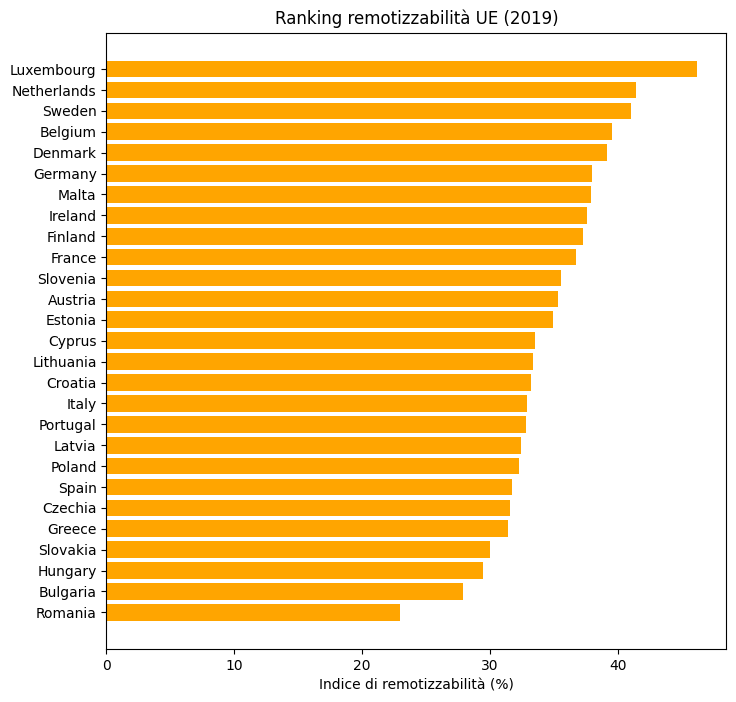

In [64]:
df_2019_sorted = df_2019.sort_values("remotizability_index")

plt.figure(figsize=(8, 8))
plt.barh(df_2019_sorted["nome_paese"], df_2019_sorted["remotizability_index"]* 100, color = "orange")
plt.xlabel("Indice di remotizzabilità (%)")
plt.title("Ranking remotizzabilità UE (2019)")
plt.show()

### come possiamo vedere dal grafico il primo paese più remotizzabile è il Lussemburgo mentre il meno remotizzabile è la Romania. L'indice del primo è circa il doppio dell'indice dell'ultimo. 

### punto 1.3

In [57]:
corr = df[var_numeriche].corr().round(3)
print(corr)

                      remotizability_index  crescita_pil  \
remotizability_index                 1.000        -0.003   
crescita_pil                        -0.003         1.000   
tasso_disoccupazione                -0.168        -0.109   
indice_produttivita                 -0.301         0.227   

                      tasso_disoccupazione  indice_produttivita  
remotizability_index                -0.168               -0.301  
crescita_pil                        -0.109                0.227  
tasso_disoccupazione                 1.000               -0.387  
indice_produttivita                 -0.387                1.000  


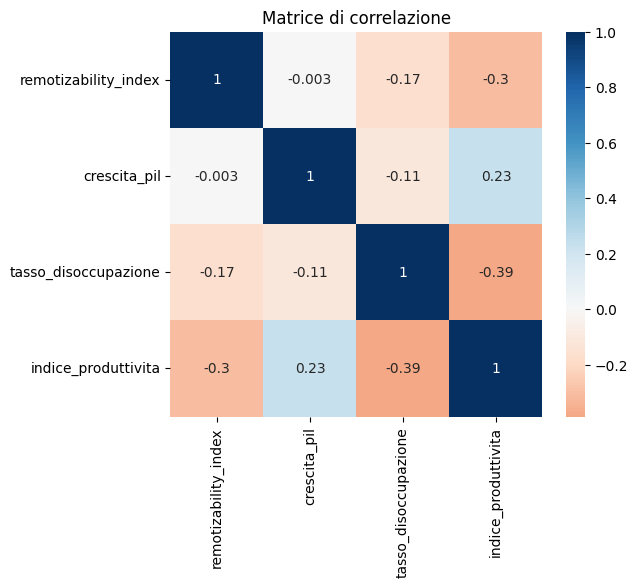

In [59]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("Matrice di correlazione")
plt.show()

### remotizability_index --> crescita_pil: r = -0.003
Correlazione praticamente zero. 
L'indice di remotizzabilità non ha nessuna relazione lineare con la crescita del PIL. Interessante perché suggerisce che essere più remotizzabile non si traduce automaticamente in crescita economica.

### remotizability_index --> tasso_disoccupazione: r = -0.17
Correlazione negativa debole. 
I paesi più remotizzabili tendono ad avere leggermente meno disoccupazione, ma il legame è molto tenue.

### remotizability_index --> indice_produttivita: r = -0.30
Correlazione negativa moderata. 
I paesi con economie più orientate ai servizi (Nord/Ovest) hanno più lavori remotizzabili, ma anche produttività più bassa rispetto ai paesi dell'Est che invece puntano sull'industria manifatturiera, settore ad alta produttività ma difficilmente remotizzabile

### crescita_pil -->  indice_produttivita: r = 0.23
Correlazione positiva debole. 
Chi cresce di più tende ad avere produttività leggermente più alta.

### tasso_disoccupazione -->  indice_produttivita: r = -0.39
La correlazione più forte in assoluto. 
I paesi con più disoccupazione hanno produttività più bassa. 